# Dysarthria Speech Classification using Acoustic Features and Machine Learning

## Problem Statement

Dysarthria is a motor speech disorder caused by neurological impairments that affect speech production. These impairments can reduce speech intelligibility and introduce acoustic variations that differ from healthy speech.

This project explores whether acoustic features extracted from speech recordings can be used to automatically distinguish dysarthric speech from non-dysarthric speech using machine learning techniques.

---

## Objectives

- Explore acoustic characteristics of dysarthric and healthy speech.
- Extract meaningful speech features from audio recordings.
- Develop machine learning models for dysarthria detection.
- Identify the most informative acoustic features.
- Build a foundation for future dysarthric speech recognition systems.

---

## Dataset

Each observation contains:

- Speech recording (.wav)
- Speaker metadata
- Gender information
- Dysarthria label

---

## Workflow

Speech Recording
↓
Signal Exploration
↓
Feature Extraction
↓
Feature Engineering
↓
Machine Learning Classification
↓
Performance Evaluation

---

## Current Scope

This notebook focuses on:

- Audio signal visualization
- Acoustic feature extraction
- MFCC feature engineering
- Machine learning classification

Future work will include additional acoustic features and deep learning approaches for speech recognition.

# Imports

In [2]:
# Standard Libraries
import os
from pathlib import Path
import IPython.display as ipd

# Data Manipulation
import numpy as np
import pandas as pd

# Audio Processing
import librosa
import librosa.display

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

## Dataset Loading and Preparation

The dataset is loaded and basic preprocessing steps are performed, including:

- Path generation for audio files
- Label encoding
- Removal of corrupted recordings

In [3]:
data_dir = Path("../data/raw")

df = pd.read_csv("../data/raw/torgo_data/data.csv")

df["filepath"] = df["filename"].apply(
    lambda x: data_dir / x
)

In [4]:
df.head()

,is_dysarthria,gender,filename,filepath
0,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session2...,..\data\raw\torgo_data\non_dysarthria_female\F...
1,non_dysarthria,female,torgo_data/non_dysarthria_female/FC02_Session3...,..\data\raw\torgo_data\non_dysarthria_female\F...
2,non_dysarthria,female,torgo_data/non_dysarthria_female/FC02_Session3...,..\data\raw\torgo_data\non_dysarthria_female\F...
3,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session2...,..\data\raw\torgo_data\non_dysarthria_female\F...
4,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session1...,..\data\raw\torgo_data\non_dysarthria_female\F...


In [5]:
df.tail()

,is_dysarthria,gender,filename,filepath
1995,dysarthria,male,torgo_data/dysarthria_male/M03_Session2_0144.wav,..\data\raw\torgo_data\dysarthria_male\M03_Ses...
1996,dysarthria,male,torgo_data/dysarthria_male/M02_Session1_0005.wav,..\data\raw\torgo_data\dysarthria_male\M02_Ses...
1997,dysarthria,male,torgo_data/dysarthria_male/M03_Session2_0040.wav,..\data\raw\torgo_data\dysarthria_male\M03_Ses...
1998,dysarthria,male,torgo_data/dysarthria_male/M03_Session2_0260.wav,..\data\raw\torgo_data\dysarthria_male\M03_Ses...
1999,dysarthria,male,torgo_data/dysarthria_male/M03_Session2_0145.wav,..\data\raw\torgo_data\dysarthria_male\M03_Ses...


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   is_dysarthria  2000 non-null   str   
 1   gender         2000 non-null   str   
 2   filename       2000 non-null   str   
 3   filepath       2000 non-null   object
dtypes: object(1), str(3)
memory usage: 62.6+ KB


In [7]:
df['gender'].value_counts()

gender
female    1000
male      1000
Name: count, dtype: int64

In [8]:
df['is_dysarthria'].value_counts()

is_dysarthria
non_dysarthria    1000
dysarthria        1000
Name: count, dtype: int64

In [9]:
pd.crosstab(df['gender'],df['is_dysarthria'])

is_dysarthria,dysarthria,non_dysarthria
gender,,
female,500,500
male,500,500


In [10]:
df["is_dysarthria"] = df["is_dysarthria"].replace({
    "non_dysarthria": 0,
    "dysarthria": 1
    })
df.head()

,is_dysarthria,gender,filename,filepath
0,0,female,torgo_data/non_dysarthria_female/FC03_Session2...,..\data\raw\torgo_data\non_dysarthria_female\F...
1,0,female,torgo_data/non_dysarthria_female/FC02_Session3...,..\data\raw\torgo_data\non_dysarthria_female\F...
2,0,female,torgo_data/non_dysarthria_female/FC02_Session3...,..\data\raw\torgo_data\non_dysarthria_female\F...
3,0,female,torgo_data/non_dysarthria_female/FC03_Session2...,..\data\raw\torgo_data\non_dysarthria_female\F...
4,0,female,torgo_data/non_dysarthria_female/FC03_Session1...,..\data\raw\torgo_data\non_dysarthria_female\F...


In [11]:
df.shape

(2000, 4)

# Remove Corrupted Files

In [12]:
corrupt_audio = df[
    df["filepath"].apply(
        lambda x: x.stat().st_size == 0
    )
]
print("corrupted Audio:",corrupt_audio['filepath'])
print("Corrupted Files:", len(corrupt_audio))

df = df[
    df["filepath"].apply(
        lambda x: x.stat().st_size > 0
    )
]

print("Updated Dataset Shape:", df.shape)

corrupted Audio: 600    ..\data\raw\torgo_data\dysarthria_female\F01_S...
Name: filepath, dtype: object
Corrupted Files: 1
Updated Dataset Shape: (1999, 4)


### Observation

The dataset contains both dysarthric and non-dysarthric speech recordings across male and female speakers.

Corrupted audio files were removed before analysis to ensure data quality and consistency during feature extraction.

## Audio Signal Inspection

Before feature extraction, a representative speech recording is examined to understand its basic characteristics, including duration, amplitude range, and sampling rate.

In [13]:
audio_path = df.iloc[0]["filepath"]

y, sr = librosa.load(
    audio_path,
    sr=None
)

print("Maximum Amplitude:", y.max())
print("Minimum Amplitude:", y.min())
print("Sample Rate:", sr)
print("Total Samples:", len(y))
print("Duration (seconds):", len(y)/sr)

Maximum Amplitude: 0.9999695
Minimum Amplitude: -1.0
Sample Rate: 16000
Total Samples: 67360
Duration (seconds): 4.21


## Representative Speech Samples

To better understand the dataset, representative recordings were selected from four speech conditions:

- Male Dysarthric
- Female Dysarthric
- Male Non-Dysarthric
- Female Non-Dysarthric

The following audio samples provide an auditory comparison of speech characteristics across conditions before performing acoustic analysis.

In [14]:
male_dys = df[(df['gender']=='male') &( df['is_dysarthria']==1)].sample(1,random_state=42)
female_dys=df[(df['gender']=='female') & (df['is_dysarthria']==1)].sample(1,random_state=42)
male_nondys=df[(df['gender']=='male' )& (df['is_dysarthria']==0)].sample(1,random_state=42)
female_nondys=df[(df['gender']=='female') &(df['is_dysarthria']==0)].sample(1,random_state=42)

In [15]:
print("Male Dysarthric")
ipd.display(ipd.Audio(male_dys.iloc[0]["filepath"]))

print("Female Dysarthric")
ipd.display(ipd.Audio(female_dys.iloc[0]["filepath"]))

print("Male Non-Dysarthric")
ipd.display(ipd.Audio(male_nondys.iloc[0]["filepath"]))

print("Female Non-Dysarthric")
ipd.display(ipd.Audio(female_nondys.iloc[0]["filepath"]))

Male Dysarthric


Female Dysarthric


Male Non-Dysarthric


Female Non-Dysarthric


## Waveform Comparison

After auditory inspection, the selected recordings are visualized in the time domain.

Waveforms illustrate amplitude variations over time and provide a first look at speech activity patterns across different speech conditions.

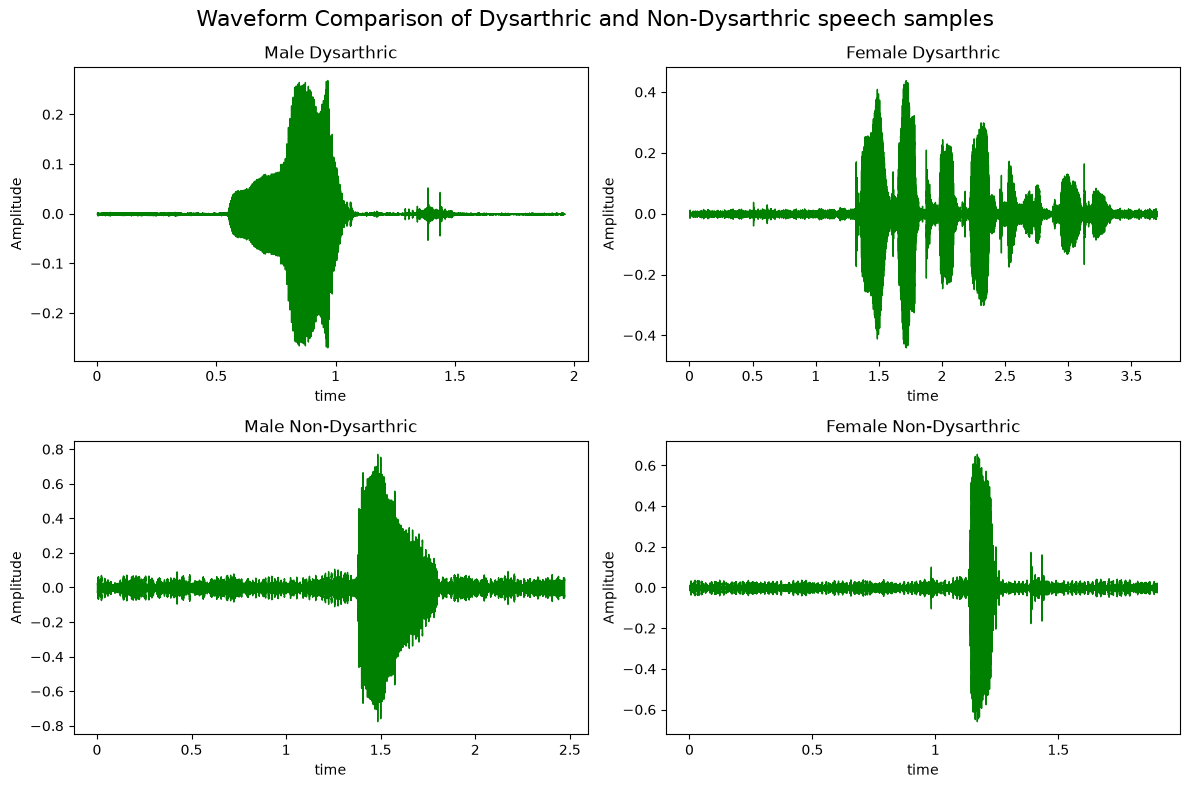

In [16]:
fig,ax=plt.subplots(2,2,figsize=(12,8))
fig.suptitle("Waveform Comparison of Dysarthric and Non-Dysarthric speech samples",fontsize=16)
samples=[(male_dys.iloc[0],"Male Dysarthric"),
         (female_dys.iloc[0],"Female Dysarthric"),
         (male_nondys.iloc[0],"Male Non-Dysarthric"),
         (female_nondys.iloc[0],"Female Non-Dysarthric")
]
for ax,(sample,title) in zip(ax.flatten(),samples):
    audio_path=sample['filepath']
    y,sr=librosa.load(audio_path)
    librosa.display.waveshow(
        y,sr=sr,ax=ax,color='green'
    )
    ax.set_title(title)
    ax.set_xlabel('time')
    ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()


### Interpretation

The waveform comparison reveals noticeable differences in speech activity patterns across the selected recordings.

The dysarthric speech samples exhibit longer speech segments and greater variability in amplitude over time, particularly in the female dysarthric recording where speech activity is distributed across a larger temporal region. In contrast, the non-dysarthric samples appear to contain more concentrated speech events with relatively well-defined energy peaks.

Differences in recording duration and amplitude distribution can also be observed across speakers, reflecting natural speaker variability as well as potential differences in speech production characteristics.

However, waveform analysis alone does not provide sufficient information for reliable dysarthria detection because time-domain signals do not explicitly capture frequency content, articulation patterns, or vocal tract characteristics. Therefore, further analysis using spectrograms and acoustic features such as MFCCs is required to better characterize the differences between dysarthric and non-dysarthric speech.

## Spectrogram Analysis

Spectrograms provide a frequency-domain representation of speech signals by showing how spectral energy changes over time.

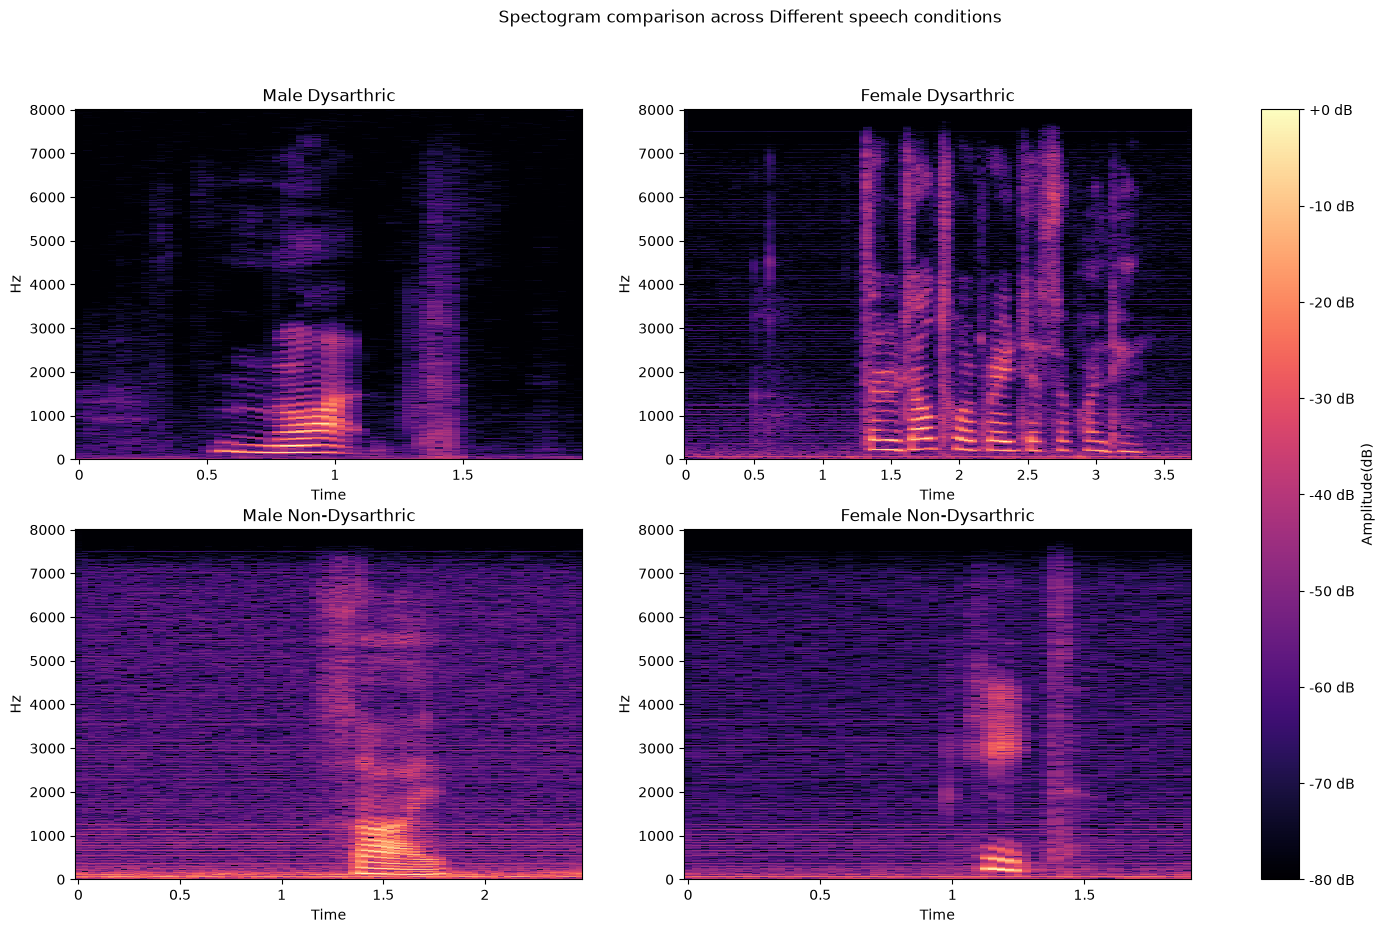

In [17]:
fig,axes = plt.subplots(2,2,figsize=(18,10))

samples = [
    (male_dys.iloc[0],"Male Dysarthric"),
    (female_dys.iloc[0],"Female Dysarthric"),
    (male_nondys.iloc[0],"Male Non-Dysarthric"),
    (female_nondys.iloc[0],"Female Non-Dysarthric")
]
for ax, (sample, title) in zip(axes.flatten(),samples):
    audio_path = sample["filepath"]
    y, sr = librosa.load(audio_path,sr=None)
    #waveform to frequency 
    D = librosa.stft(y) 
    # decibal conversion
    D_db = librosa.amplitude_to_db(
        np.abs(D),
        ref=np.max
    )

    img = librosa.display.specshow(
        D_db,
        sr=sr,
        x_axis="time",
        y_axis="hz",
        cmap="magma",
        ax=ax
    )

    ax.set_title(title)

c_bar=fig.colorbar(
    img,
    ax=axes,
    format="%+2.0f dB"
)
c_bar.set_label('Amplitude(dB)')
fig.suptitle("Spectogram comparison across Different speech conditions")
plt.show()

### Interpretation

The spectrogram comparison reveals differences in the temporal and spectral distribution of speech energy across the selected recordings.

The dysarthric speech samples exhibit speech activity distributed over longer time intervals, with energy spread across a broader range of frequencies. Multiple regions of high-energy concentration can be observed throughout the recordings, indicating greater temporal variability in speech production.

In contrast, the non-dysarthric samples display more localized high-energy regions, with speech energy concentrated within shorter temporal segments. The spectral structure also appears more compact, particularly in the female non-dysarthric recording.

Across all samples, the majority of speech energy is concentrated in the lower frequency bands, which is consistent with the characteristics of human speech production. However, noticeable differences in the distribution and continuity of spectral energy suggest that frequency-domain representations may capture information relevant for distinguishing dysarthric and non-dysarthric speech.

These observations motivate the use of acoustic features such as MFCCs, spectral centroid, and energy-based descriptors for machine learning classification.

## RMS Energy Analysis

Root Mean Square (RMS) energy measures short-term speech intensity and reflects how speech energy changes throughout an utterance.

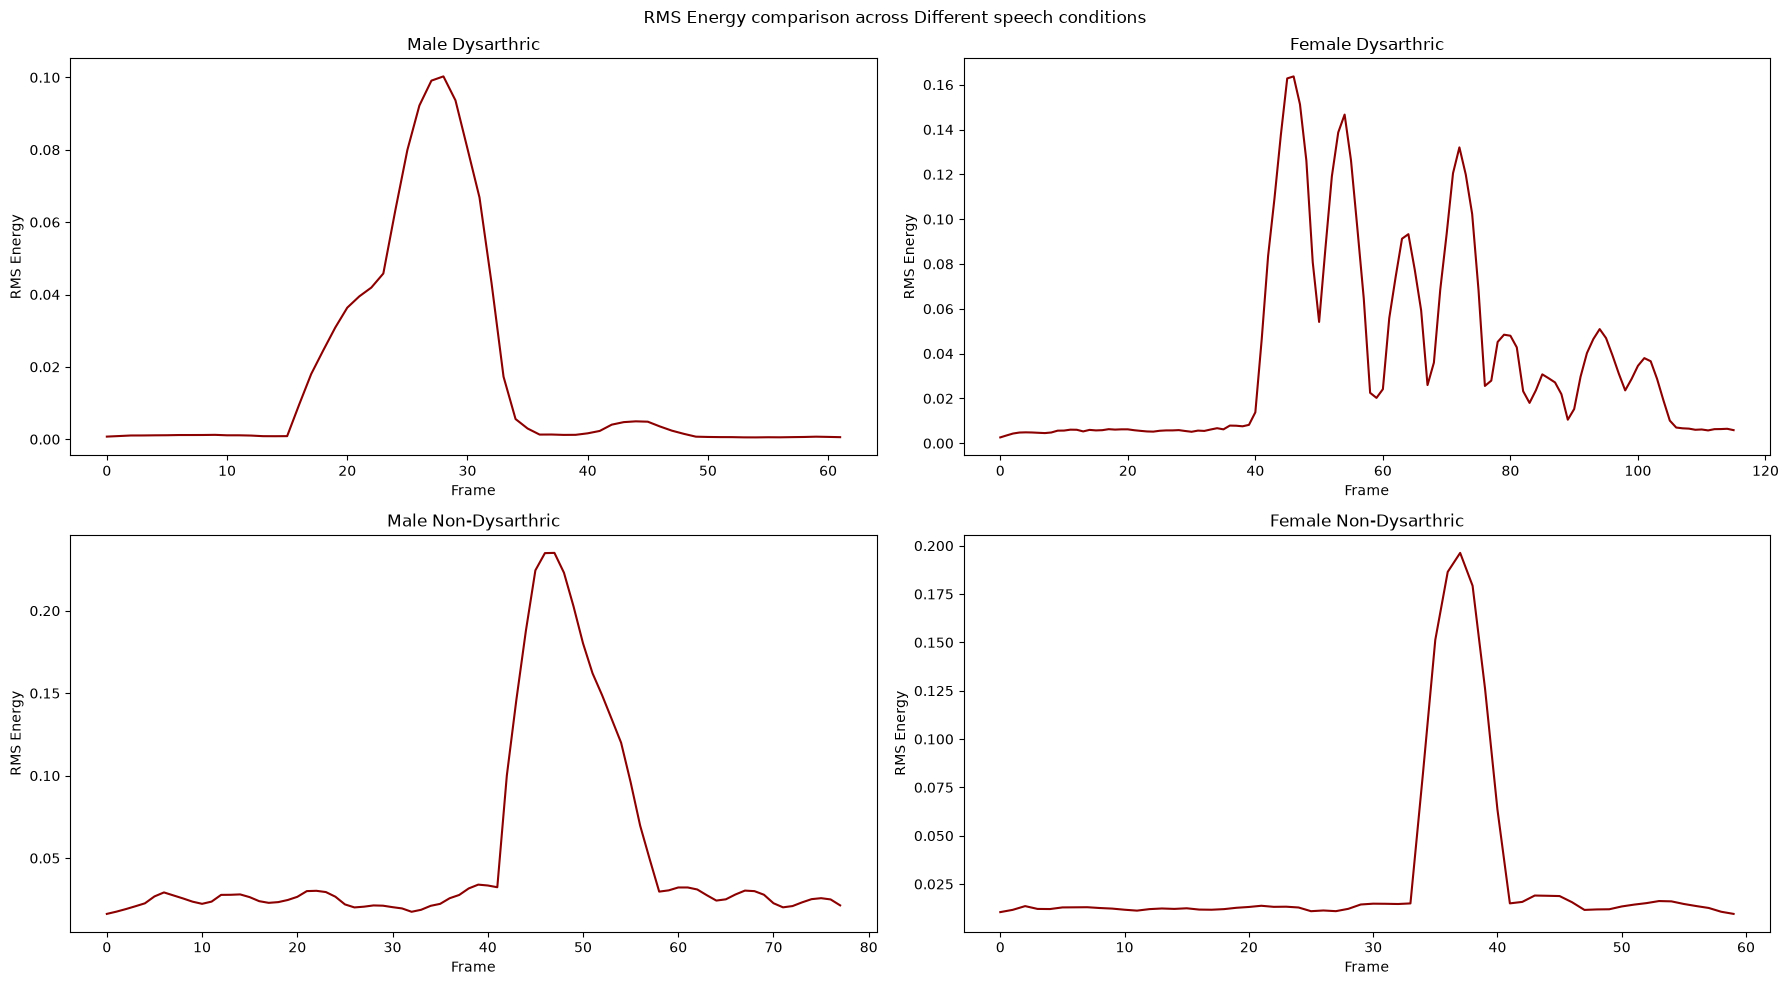

In [18]:
fig,ax = plt.subplots(2,2,figsize=(18,10),)
fig.suptitle("RMS Energy comparison across Different speech conditions")
samples = [
    (male_dys.iloc[0],"Male Dysarthric"),
    (female_dys.iloc[0],"Female Dysarthric"),
    (male_nondys.iloc[0],"Male Non-Dysarthric"),
    (female_nondys.iloc[0],"Female Non-Dysarthric")
]
for ax, (sample, title) in zip(ax.flatten(),samples):
    audio_path = sample["filepath"]
    y, sr = librosa.load(audio_path,sr=None)
    rms=librosa.feature.rms(y=y)[0]
    ax.plot(rms,color='darkred')

    ax.set_title(title)
    ax.set_xlabel("Frame")
    ax.set_ylabel("RMS Energy")

plt.tight_layout()
plt.show()

### Interpretation

The RMS energy comparison highlights differences in the temporal distribution of speech energy across the selected recordings.

The dysarthric speech samples exhibit multiple energy peaks distributed over a larger number of frames, indicating greater variability in speech intensity throughout the utterance. In particular, the female dysarthric recording shows several distinct energy fluctuations rather than a single dominant peak.

In contrast, the non-dysarthric recordings display more concentrated energy patterns, characterized by a prominent peak occurring within a relatively narrow time interval. This suggests that speech energy is focused within a shorter and more localized segment of the recording.

These observations indicate that RMS energy may capture differences in speech production dynamics and temporal energy distribution between dysarthric and non-dysarthric speech. Consequently, RMS-based statistics could provide useful complementary features for machine learning classification.

## Zero Crossing Rate Analysis

Zero Crossing Rate (ZCR) measures how frequently the waveform changes sign and provides information about signal frequency characteristics.

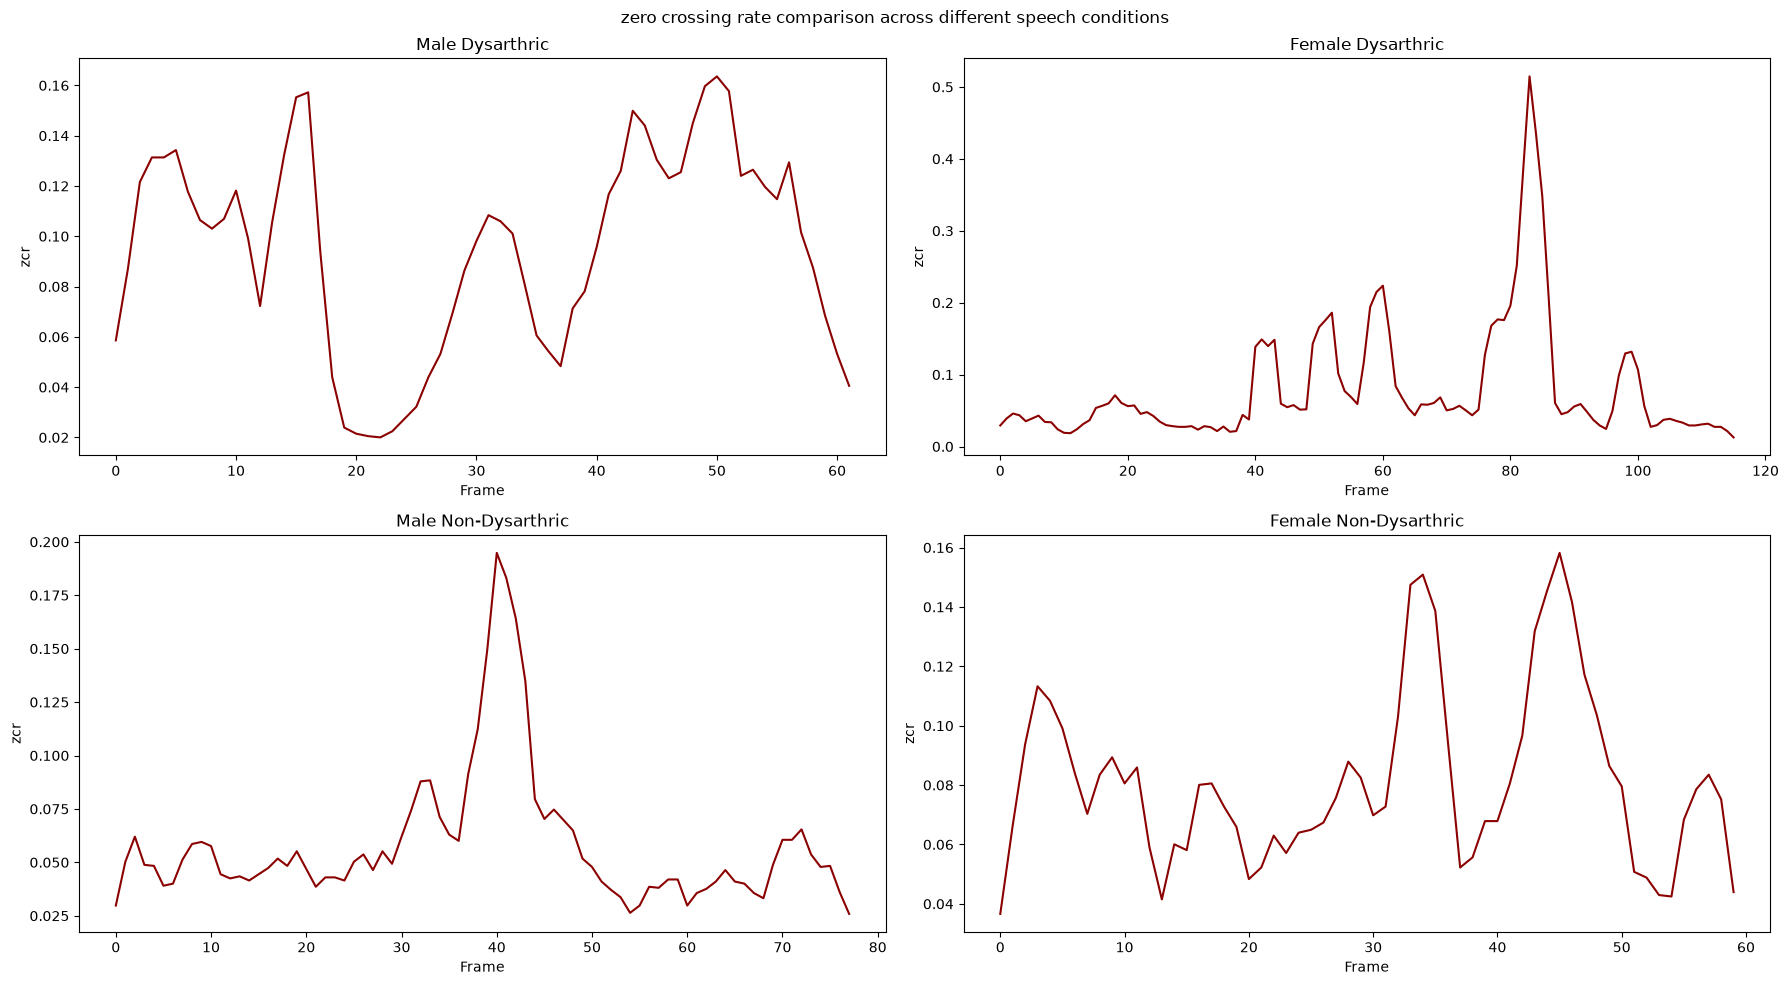

In [19]:
fig,ax = plt.subplots(2,2,figsize=(18,10))
fig.suptitle("zero crossing rate comparison across different speech conditions")
samples = [
    (male_dys.iloc[0],"Male Dysarthric"),
    (female_dys.iloc[0],"Female Dysarthric"),
    (male_nondys.iloc[0],"Male Non-Dysarthric"),
    (female_nondys.iloc[0],"Female Non-Dysarthric")
]
for ax, (sample, title) in zip(ax.flatten(),samples):
    audio_path = sample["filepath"]
    y, sr = librosa.load(audio_path,sr=None)
    zcr=librosa.feature.zero_crossing_rate(y=y)[0]
    ax.plot(zcr,color='darkred')

    ax.set_title(title)
    ax.set_xlabel("Frame")
    ax.set_ylabel("zcr")

plt.tight_layout()
plt.show()

### Interpretation

The Zero Crossing Rate (ZCR) comparison illustrates variations in signal complexity and frequency-related characteristics across the selected speech recordings.

All recordings exhibit fluctuations in ZCR over time, reflecting changes in speech articulation and spectral content throughout the utterance. Both dysarthric and non-dysarthric samples contain periods of elevated ZCR, indicating regions with greater high-frequency activity or rapid waveform changes.

The dysarthric recordings generally display greater variability in ZCR across multiple frames, while the non-dysarthric recordings tend to exhibit more localized peaks. However, considerable overlap is observed between the two groups, suggesting that ZCR alone may not be sufficient for reliable dysarthria detection.

Nevertheless, ZCR may provide complementary information when combined with other acoustic features such as MFCCs, RMS energy, and spectral descriptors within a machine learning framework.

## Spectral Centroid Analysis

The spectral centroid indicates the center of mass of the frequency spectrum and is often associated with the perceived brightness of speech.

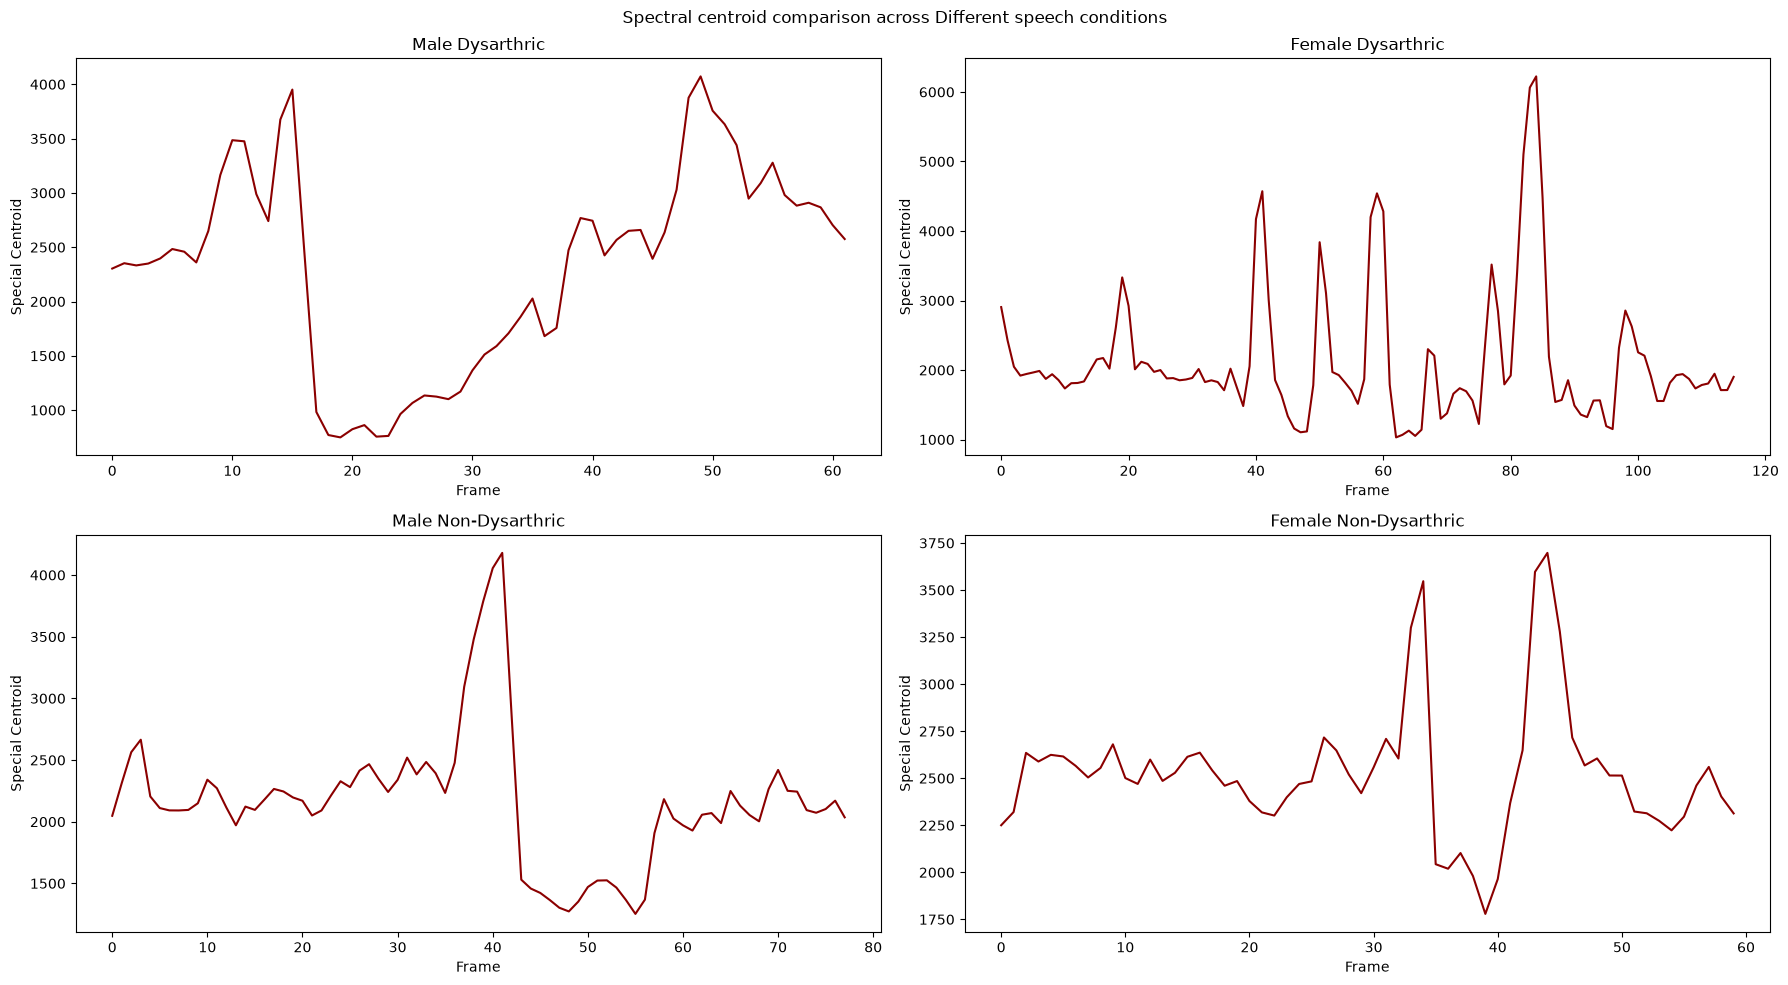

In [20]:
fig,ax = plt.subplots(2,2,figsize=(18,10))
fig.suptitle("Spectral centroid comparison across Different speech conditions")
samples = [
    (male_dys.iloc[0],"Male Dysarthric"),
    (female_dys.iloc[0],"Female Dysarthric"),
    (male_nondys.iloc[0],"Male Non-Dysarthric"),
    (female_nondys.iloc[0],"Female Non-Dysarthric")
]
for ax, (sample, title) in zip(ax.flatten(),samples):
    audio_path = sample["filepath"]
    y, sr = librosa.load(audio_path,sr=None)
    centroid=librosa.feature.spectral_centroid(y=y)[0]
    ax.plot(centroid,color='darkred')

    ax.set_title(title)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Special Centroid")

plt.tight_layout()
plt.show()

### Interpretation

The spectral centroid comparison illustrates how the distribution of spectral energy changes throughout each speech recording. Higher centroid values indicate that energy is concentrated at higher frequencies, whereas lower values suggest that energy is concentrated in lower frequency regions.

Across the selected recordings, noticeable fluctuations in spectral centroid trajectories can be observed. The dysarthric speech samples exhibit larger variations and several abrupt peaks, indicating greater temporal variability in the frequency distribution of speech energy. In particular, the female dysarthric recording shows multiple high-centroid peaks throughout the utterance.

The non-dysarthric recordings generally display more stable centroid patterns, with fewer extreme fluctuations and more consistent frequency energy distribution over time. Although temporary shifts are still present, the overall trajectories appear comparatively smoother.

These observations suggest that spectral centroid features may capture differences in articulation behavior and spectral energy distribution between dysarthric and non-dysarthric speech. Consequently, centroid-based statistics may provide useful complementary information when combined with MFCCs, RMS energy, and other acoustic descriptors for classification.

## MFCC Feature Extraction

Mel Frequency Cepstral Coefficients (MFCCs) are among the most widely used acoustic features in speech processing.

MFCCs capture spectral envelope information that reflects vocal tract characteristics and articulation behavior.

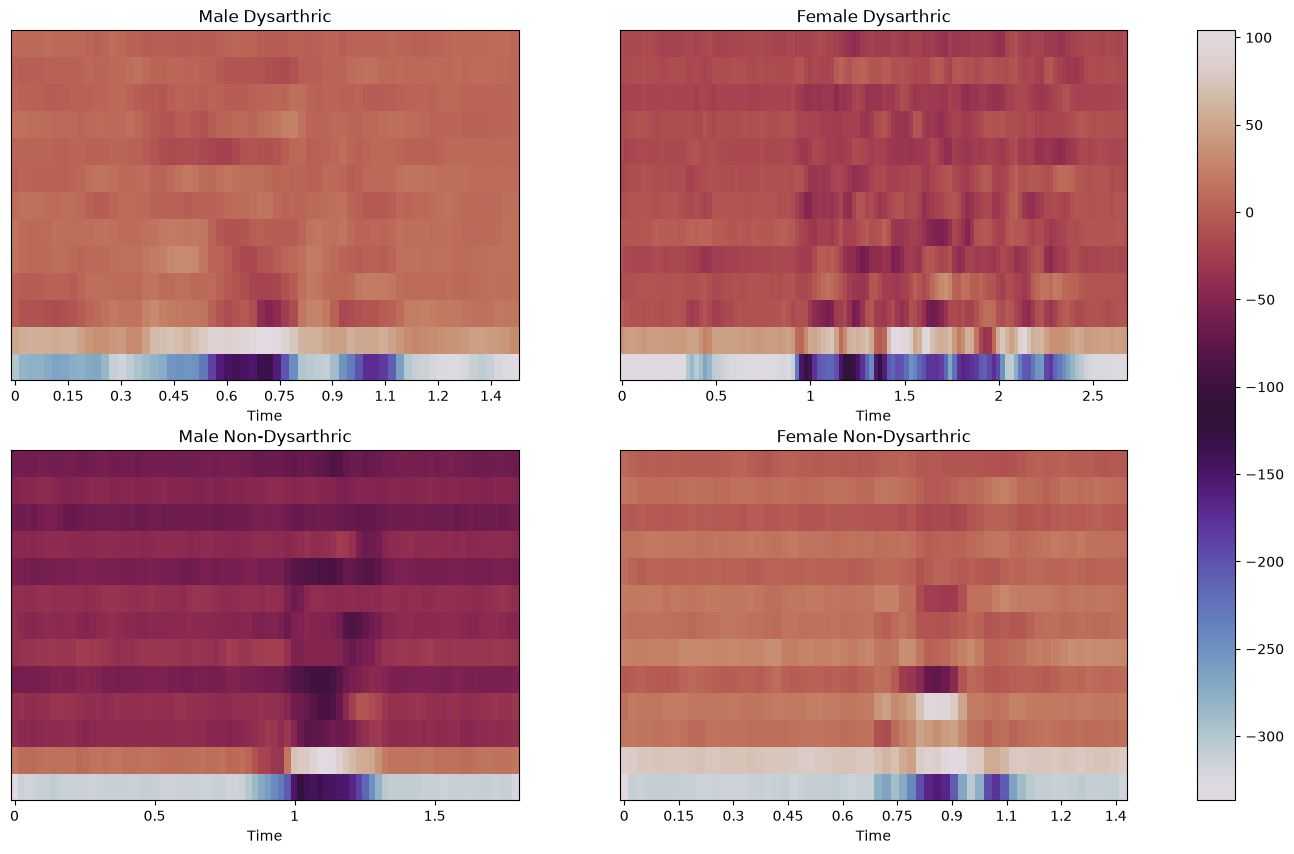

In [21]:
fig,axes = plt.subplots(2,2,figsize=(18,10))

samples = [
    (male_dys.iloc[0],"Male Dysarthric"),
    (female_dys.iloc[0],"Female Dysarthric"),
    (male_nondys.iloc[0],"Male Non-Dysarthric"),
    (female_nondys.iloc[0],"Female Non-Dysarthric")
]

for ax,(sample,title) in zip(axes.flatten(),samples):
    y, sr = librosa.load(
        sample["filepath"],
        sr=None
    )

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
    )

    img = librosa.display.specshow(
        mfcc,
        x_axis="time",
        cmap="twilight",
        ax=ax
    )

    ax.set_title(title)

fig.colorbar(img, ax=axes)
plt.show()

### Interpretation

The MFCC heatmaps reveal differences in cepstral patterns across the selected speech recordings. MFCCs provide a compact representation of the speech spectrum and capture characteristics related to vocal tract configuration, articulation, and speech production.

The dysarthric recordings exhibit greater variation in coefficient values across time, with more pronounced changes in intensity and distribution throughout the utterance. In contrast, the non-dysarthric recordings appear to display more stable and structured MFCC patterns, with energy concentrated within shorter temporal regions.

Distinct coefficient trajectories can be observed across all speech conditions, indicating that each recording possesses unique spectral characteristics. These differences suggest that MFCCs effectively capture information related to speech production and may provide discriminative features for distinguishing dysarthric and non-dysarthric speech.

Given their ability to represent perceptually relevant acoustic information, MFCCs form the primary feature set used in the subsequent machine learning classification experiments.

The visual differences observed in the MFCC representations are consistent with the strong classification performance achieved by the machine learning models, suggesting that MFCC-derived statistics capture important acoustic characteristics associated with dysarthric speech.

In [22]:
mfcc.shape

(13, 60)

In [23]:
mfcc_tab=pd.DataFrame(
    mfcc,
    index=[f"MFCC{i}" for i in range(1,14) ]
)
mfcc_tab

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
MFCC1,-336.834686,-310.689850,-313.839783,-309.872528,-309.700256,-309.952789,-309.432159,-311.261841,-312.142120,-314.989868,...,-310.006470,-311.739563,-311.463440,-308.948303,-305.706299,-309.186035,-310.555511,-308.904938,-307.941895,-317.518066
MFCC2,83.615807,81.228279,75.614136,76.386353,73.662575,74.970802,75.755516,74.730843,74.309021,71.763855,...,75.288750,77.333542,73.577583,75.530991,79.563675,75.106262,73.540810,73.856888,78.022766,81.322838
MFCC3,15.836612,17.292114,15.261358,16.094166,13.510033,14.106115,16.468061,13.878565,7.808298,7.519271,...,15.999018,12.566912,9.881577,10.407866,11.728035,8.943016,10.556360,10.909641,11.008610,12.694446
MFCC4,11.931560,19.202984,17.911905,16.281385,17.340973,20.135969,21.486912,21.420525,17.655010,16.481392,...,19.192215,18.708498,18.636999,17.712933,20.001297,21.357084,18.324602,16.144957,17.647675,20.526047
MFCC5,-3.448472,-2.119134,1.159650,-1.592621,-2.875422,-3.446090,-1.591845,3.855910,7.496720,5.882254,...,-2.745445,2.814576,8.877669,8.486791,5.757962,11.200724,7.540796,4.801421,6.395017,9.734011
MFCC6,25.164772,23.608242,23.433723,24.206732,25.958559,23.868584,24.676910,30.254660,28.837746,29.175867,...,20.627306,24.960007,29.104126,33.621857,31.174648,33.589191,30.604982,30.549263,32.092075,28.727573
MFCC7,16.647770,12.524528,12.820669,13.606396,13.717735,12.669660,13.185933,11.466938,8.352940,12.230465,...,11.897369,12.666550,7.903944,9.347355,12.896667,11.405207,8.889108,9.694644,11.717548,11.692221
MFCC8,19.622107,18.457741,18.450737,20.387463,20.006176,15.284443,19.849253,16.905499,15.260541,16.999073,...,21.349985,16.948154,13.788654,17.801792,18.119854,14.957977,16.641661,16.742685,15.629703,13.632354
MFCC9,11.853405,5.676376,-0.879058,3.374090,4.902906,3.170680,3.145950,2.948272,4.621375,1.451723,...,6.264275,4.857353,5.186695,7.615020,6.122428,1.142489,3.462325,5.510326,3.962921,3.263585
MFCC10,15.372507,14.960755,15.572107,19.090816,18.826145,17.633881,17.641291,17.923185,16.341805,13.612083,...,15.667000,20.940804,17.647430,15.497683,19.305878,14.399950,13.942856,12.544479,12.515350,12.173941


## Statistical Feature Engineering

For each MFCC coefficient, four statistical descriptors are computed:

- Mean
- Standard Deviation
- Minimum
- Maximum

This results in 52 MFCC-based features per recording.

In [24]:
mfcc_mean=np.mean(mfcc,axis=1)
pd.Series(mfcc_mean,index=[f"MFCC{i}" for i in range(1,14)])

MFCC1    -288.855804
MFCC2      75.525108
MFCC3      14.746402
MFCC4      26.673031
MFCC5      -4.199951
MFCC6      23.636089
MFCC7       8.527655
MFCC8      13.591475
MFCC9       2.833682
MFCC10     13.780703
MFCC11     -5.220496
MFCC12     10.512784
MFCC13     -1.761584
dtype: float32

In [25]:
mfcc_std=np.std(mfcc,axis=1)
pd.Series(mfcc_std,index=[f"MFCC{i}" for i in range(1,14)])

MFCC1     44.215797
MFCC2      8.867929
MFCC3     10.761849
MFCC4     19.733713
MFCC5     18.708593
MFCC6      8.162065
MFCC7      7.527743
MFCC8     12.708178
MFCC9      3.566735
MFCC10     4.540133
MFCC11     4.920774
MFCC12     4.801840
MFCC13     3.738794
dtype: float32

In [26]:
print("MFCC Min")
mfcc_min=np.min(mfcc,axis=1)
print(pd.Series(mfcc_min,index=[f"MFCC{i}" for i in range(1,14)]))

MFCC Min
MFCC1    -336.834686
MFCC2      47.309517
MFCC3     -13.558968
MFCC4      11.931560
MFCC5     -74.546326
MFCC6       1.581974
MFCC7      -9.309206
MFCC8     -29.215727
MFCC9      -8.666939
MFCC10     -0.781620
MFCC11    -19.443663
MFCC12     -4.242572
MFCC13    -10.748468
dtype: float32


In [27]:
print("\nMFCC Max")
mfcc_max=np.max(mfcc,axis=1)
pd.Series(mfcc_max,index=[f"MFCC{i}" for i in range(1,14)])


MFCC Max


MFCC1    -157.415573
MFCC2     103.960968
MFCC3      49.417648
MFCC4      95.698151
MFCC5      12.477962
MFCC6      34.327332
MFCC7      17.097208
MFCC8      29.595922
MFCC9      11.853405
MFCC10     20.940804
MFCC11      2.951935
MFCC12     23.853643
MFCC13      7.557258
dtype: float32

In [28]:
features = {}

for i in range(13):

    features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])

    features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    features[f"mfcc_{i+1}_min"] = np.min(mfcc[i])

    features[f"mfcc_{i+1}_max"] = np.max(mfcc[i])

features

{'mfcc_1_mean': np.float32(-288.8558),
 'mfcc_1_std': np.float32(44.215797),
 'mfcc_1_min': np.float32(-336.8347),
 'mfcc_1_max': np.float32(-157.41557),
 'mfcc_2_mean': np.float32(75.52511),
 'mfcc_2_std': np.float32(8.867929),
 'mfcc_2_min': np.float32(47.309517),
 'mfcc_2_max': np.float32(103.96097),
 'mfcc_3_mean': np.float32(14.746402),
 'mfcc_3_std': np.float32(10.761849),
 'mfcc_3_min': np.float32(-13.558968),
 'mfcc_3_max': np.float32(49.41765),
 'mfcc_4_mean': np.float32(26.67303),
 'mfcc_4_std': np.float32(19.733713),
 'mfcc_4_min': np.float32(11.93156),
 'mfcc_4_max': np.float32(95.69815),
 'mfcc_5_mean': np.float32(-4.199951),
 'mfcc_5_std': np.float32(18.708593),
 'mfcc_5_min': np.float32(-74.546326),
 'mfcc_5_max': np.float32(12.4779625),
 'mfcc_6_mean': np.float32(23.63609),
 'mfcc_6_std': np.float32(8.162065),
 'mfcc_6_min': np.float32(1.5819737),
 'mfcc_6_max': np.float32(34.32733),
 'mfcc_7_mean': np.float32(8.527655),
 'mfcc_7_std': np.float32(7.527743),
 'mfcc_7_min

In [29]:
def extract_mfcc_features(audio_path):

    y, sr = librosa.load(
        audio_path,
        sr=None
    )

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    features = {}

    for i in range(13):

        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])

        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

        features[f"mfcc_{i+1}_min"] = np.min(mfcc[i])

        features[f"mfcc_{i+1}_max"] = np.max(mfcc[i])

    return features

In [30]:
extract_mfcc_features(
    df.iloc[0]["filepath"]
)

{'mfcc_1_mean': np.float32(-191.00879),
 'mfcc_1_std': np.float32(96.48995),
 'mfcc_1_min': np.float32(-325.07953),
 'mfcc_1_max': np.float32(26.155708),
 'mfcc_2_mean': np.float32(73.62102),
 'mfcc_2_std': np.float32(27.256504),
 'mfcc_2_min': np.float32(-24.334995),
 'mfcc_2_max': np.float32(149.93819),
 'mfcc_3_mean': np.float32(3.1847997),
 'mfcc_3_std': np.float32(23.55564),
 'mfcc_3_min': np.float32(-55.670334),
 'mfcc_3_max': np.float32(63.69491),
 'mfcc_4_mean': np.float32(20.472912),
 'mfcc_4_std': np.float32(17.379745),
 'mfcc_4_min': np.float32(-18.151638),
 'mfcc_4_max': np.float32(88.20104),
 'mfcc_5_mean': np.float32(-1.684721),
 'mfcc_5_std': np.float32(14.699628),
 'mfcc_5_min': np.float32(-60.628624),
 'mfcc_5_max': np.float32(23.800219),
 'mfcc_6_mean': np.float32(11.593274),
 'mfcc_6_std': np.float32(14.230458),
 'mfcc_6_min': np.float32(-27.40622),
 'mfcc_6_max': np.float32(38.8211),
 'mfcc_7_mean': np.float32(-2.840228),
 'mfcc_7_std': np.float32(12.916149),
 'mfcc

In [31]:
feature_list=[]
for row in df.itertuples():
    feature_dict=extract_mfcc_features(
        row.filepath
    )
    feature_dict['label']=row.is_dysarthria
    feature_list.append(feature_dict)
mfcc_df=pd.DataFrame(feature_list)

c:\Dysartria Speech Classification\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=151
  warnings.warn(
c:\Dysartria Speech Classification\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=423
  warnings.warn(
c:\Dysartria Speech Classification\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=421
  warnings.warn(
c:\Dysartria Speech Classification\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=134
  warnings.warn(
c:\Dysartria Speech Classification\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=686
  warnings.warn(
c:\Dysartria Speech Classification\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for 

In [32]:
mfcc_df.head()

,mfcc_1_mean,mfcc_1_std,mfcc_1_min,mfcc_1_max,mfcc_2_mean,mfcc_2_std,mfcc_2_min,mfcc_2_max,mfcc_3_mean,mfcc_3_std,...,mfcc_11_max,mfcc_12_mean,mfcc_12_std,mfcc_12_min,mfcc_12_max,mfcc_13_mean,mfcc_13_std,mfcc_13_min,mfcc_13_max,label
0,-191.008789,96.489952,-325.079529,26.155708,73.621017,27.256504,-24.334995,149.938187,3.184800,23.555639,...,13.408217,8.219816,7.108309,-16.270800,24.096546,-0.517066,5.263089,-13.906329,12.818811,0
1,-271.245300,73.674294,-337.309967,-94.176529,79.915596,35.047585,-4.986001,168.564606,2.773101,19.324028,...,6.853100,12.043371,3.568896,3.974150,24.483128,-0.801480,4.133411,-16.967503,5.149189,0
2,-270.576904,76.247238,-337.650818,-48.841431,77.244087,10.517373,59.061012,128.640305,1.497219,18.190102,...,18.836660,11.360298,6.377625,-14.321575,29.917070,-1.681518,4.658833,-16.285585,12.217577,0
3,-171.391724,91.264320,-326.912964,-19.293163,79.037689,31.201159,-14.771301,177.233490,-10.014421,26.604675,...,9.825926,9.945725,9.492010,-12.872565,34.637238,-0.838221,5.604954,-13.022116,16.155668,0
4,-249.714325,64.152710,-324.610260,-80.193680,71.885529,27.395239,4.859882,168.197357,6.370343,19.937794,...,13.708227,10.401051,4.635783,-4.919951,20.069698,-2.205479,6.672813,-18.923670,13.367812,0


In [33]:
mfcc_df.shape

(1999, 53)

In [34]:
results = []

for feature in features:

    dys_mean = mfcc_df[
        mfcc_df["label"]==1
    ][feature].mean()

    non_mean = mfcc_df[
        mfcc_df["label"]==0
    ][feature].mean()

    results.append([
        feature,
        abs(dys_mean-non_mean)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "Difference"
    ]
)

results_df.sort_values(
    "Difference",
    ascending=False
)

,Feature,Difference
2,mfcc_1_min,81.227295
0,mfcc_1_mean,60.630829
1,mfcc_1_std,21.668625
3,mfcc_1_max,18.725746
26,mfcc_7_min,11.629450
19,mfcc_5_max,9.653431
22,mfcc_6_min,8.991317
46,mfcc_12_min,8.073246
7,mfcc_2_max,6.221527
10,mfcc_3_min,5.993885


## Feature Distribution Analysis

Before training machine learning models, it is useful to examine whether extracted acoustic features exhibit different distributions across speech conditions.

The following visualization compares the distribution of the first MFCC coefficient mean between dysarthric and non-dysarthric recordings.

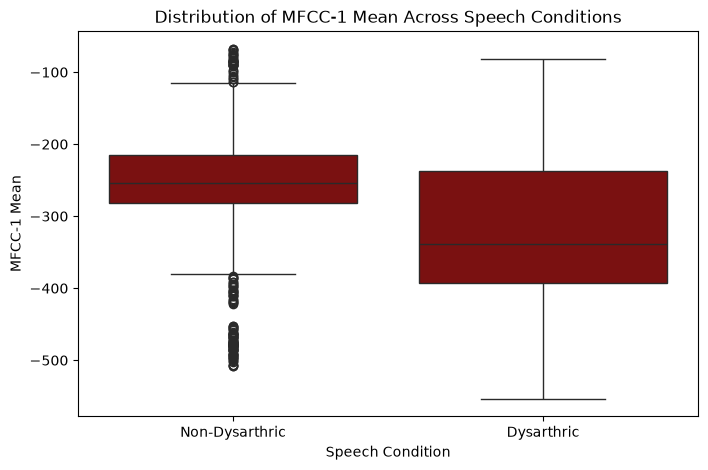

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=mfcc_df,
    x="label",
    y="mfcc_1_mean",
    color='darkred'
)

plt.xticks(
    [0,1],
    ["Non-Dysarthric","Dysarthric"]
)

plt.xlabel("Speech Condition")
plt.ylabel("MFCC-1 Mean")

plt.title("Distribution of MFCC-1 Mean Across Speech Conditions")

plt.show()

### Interpretation

The boxplot compares the distribution of the mean value of the first MFCC coefficient (MFCC-1) between dysarthric and non-dysarthric speech recordings.

A noticeable shift in the distributions can be observed between the two groups. The dysarthric recordings generally exhibit lower MFCC-1 mean values compared to the non-dysarthric recordings, indicating differences in the underlying spectral characteristics of the speech signals.

The dysarthric group also displays a wider spread of values, suggesting greater variability in speech production across affected speakers. Although some overlap exists between the two distributions, the separation between their median values indicates that MFCC-1 contains information that may help distinguish between the two speech conditions.

These observations support the use of MFCC-derived features for machine learning classification and suggest that acoustic differences associated with dysarthria are reflected in the cepstral domain.

The observed separation between the two distributions suggests that MFCC-based statistics capture acoustic characteristics relevant to dysarthria detection, motivating their use as inputs for supervised machine learning models.

## Machine Learning Classification

The engineered MFCC features are used to train multiple supervised learning models:

- Logistic Regression
- Random Forest
- Support Vector Machine
- K-Nearest Neighbors

Performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

In [36]:
# Features
X = mfcc_df.drop("label", axis=1)

# Labels
y = mfcc_df["label"]

print(X.shape)
print(y.shape)

(1999, 52)
(1999,)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1599, 52)
(400, 52)


In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=2000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "SVM":
        SVC(probability=True),

    "KNN":
        KNeighborsClassifier(n_neighbors=5)

}

# Results Table

In [40]:
results = []

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = model.predict(
        X_test_scaled
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred
    )

    rec = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    results.append([
        name,
        acc,
        prec,
        rec,
        f1
    ])

c:\Dysartria Speech Classification\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [41]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    "F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.9400,0.944444,0.935,0.939698
2,SVM,0.9400,0.948980,0.930,0.939394
3,KNN,0.9325,0.972678,0.890,0.929504
0,Logistic Regression,0.8650,0.868687,0.860,0.864322


## Model Performance Summary

Among the evaluated models, Random Forest and Support Vector Machine achieved the strongest overall performance, with F1 scores around 94%.

These results indicate that MFCC-based acoustic features contain sufficient information to effectively distinguish dysarthric and non-dysarthric speech recordings.

## Confusion Matrix Analysis

Random Forest achieved the strongest overall performance among the evaluated machine learning models. To better understand its classification behavior, a confusion matrix is examined to visualize correct and incorrect predictions across both speech conditions.

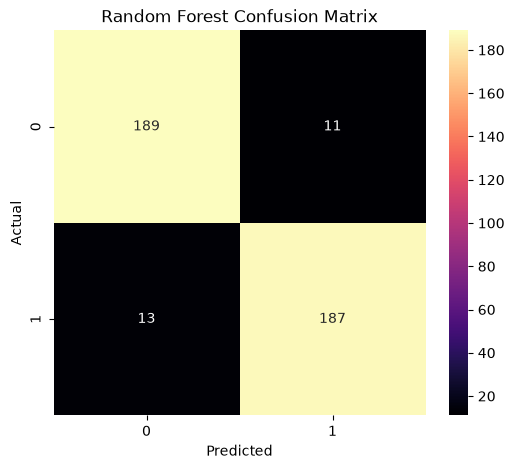

In [42]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train_scaled,
    y_train
)

y_pred = rf.predict(
    X_test_scaled
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### Interpretation

The confusion matrix demonstrates strong classification performance of the Random Forest model on the test set.

The model correctly classified 189 non-dysarthric recordings and 187 dysarthric recordings, resulting in a total of 376 correct predictions out of 400 test samples. Only 24 recordings were misclassified.

The relatively small number of false positives (11) and false negatives (13) indicates that the model is able to distinguish between dysarthric and non-dysarthric speech with a high degree of accuracy.

The balanced distribution of errors across both classes suggests that the model does not exhibit a strong bias toward either speech condition. This result supports the effectiveness of MFCC-derived acoustic features for automated dysarthria detection.

Overall, the confusion matrix confirms that the Random Forest classifier achieves reliable performance and is capable of accurately identifying speech recordings from both classes.

In [43]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
2,mfcc_1_min,0.123188
0,mfcc_1_mean,0.083776
44,mfcc_12_mean,0.066294
3,mfcc_1_max,0.048412
25,mfcc_7_std,0.043772
26,mfcc_7_min,0.038174
20,mfcc_6_mean,0.031406
46,mfcc_12_min,0.024878
16,mfcc_5_mean,0.023297
1,mfcc_1_std,0.022726


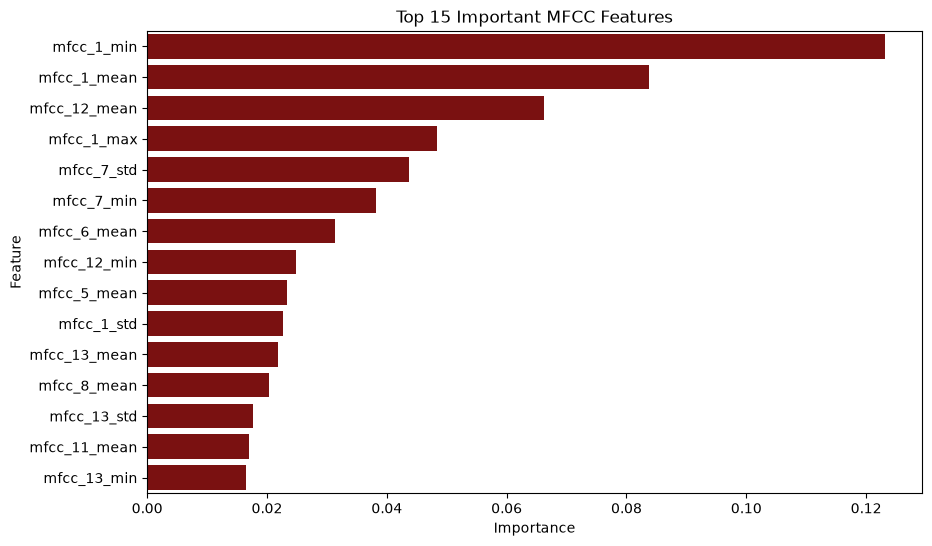

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature",
    color='darkred'
)

plt.title(
    "Top 15 Important MFCC Features"
)

plt.show()

### Interpretation

The feature importance analysis highlights the MFCC-derived statistics that contribute most strongly to the Random Forest classification decisions.

Several MFCC features exhibit substantially higher importance scores than others, indicating that certain cepstral characteristics carry more discriminative information regarding dysarthric speech. These influential features likely capture differences in articulation patterns, vocal tract behavior, and spectral structure between the two speech conditions.

The results demonstrate that not all acoustic features contribute equally to classification performance. Identifying the most informative features can improve model interpretability and guide future feature engineering efforts.

Overall, the feature importance analysis provides additional evidence that MFCC-based acoustic representations are effective for distinguishing dysarthric and non-dysarthric speech recordings.

# Cross-Validation Analysis

A single train-test split provides an estimate of model performance, but the results may vary depending on how the data is partitioned.

To obtain a more robust evaluation, Stratified K-Fold Cross-Validation is performed. This technique divides the dataset into multiple folds while preserving the class distribution in each fold. The model is trained and evaluated across all folds, and the performance metrics are averaged.

Cross-validation provides a more reliable estimate of the model's generalization capability and helps determine whether the observed performance is consistent across different data partitions.

### Random Forest Cross Validation

In [45]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

print("Accuracy :", scores["test_accuracy"])
print("Precision:", scores["test_precision"])
print("Recall   :", scores["test_recall"])
print("F1 Score :", scores["test_f1"])

Accuracy : [0.955      0.95       0.9475     0.9325     0.92982456]
Precision: [0.95049505 0.95       0.94527363 0.92610837 0.94300518]
Recall   : [0.96       0.95       0.95       0.94       0.91457286]
F1 Score : [0.95522388 0.95       0.94763092 0.93300248 0.92857143]


In [46]:
cv_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Mean":[
        scores["test_accuracy"].mean(),
        scores["test_precision"].mean(),
        scores["test_recall"].mean(),
        scores["test_f1"].mean()
    ],
    "Std":[
        scores["test_accuracy"].std(),
        scores["test_precision"].std(),
        scores["test_recall"].std(),
        scores["test_f1"].std()
    ]
})

cv_results

,Metric,Mean,Std
0,Accuracy,0.942965,0.009971
1,Precision,0.942976,0.008896
2,Recall,0.942915,0.015518
3,F1 Score,0.942886,0.010276


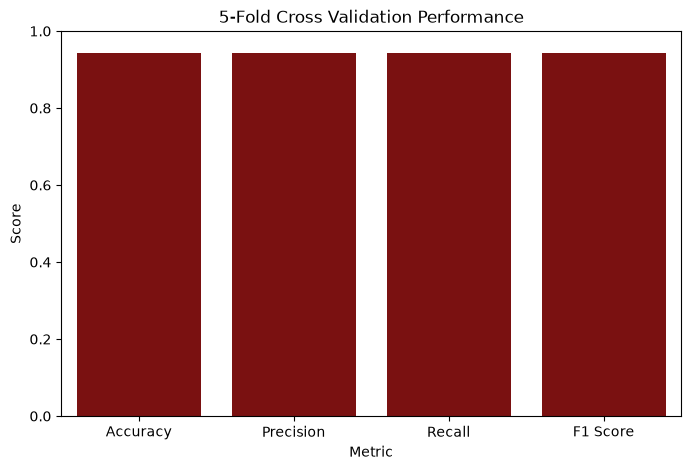

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cv_results,
    x="Metric",
    y="Mean",
    color='darkred'
)

plt.ylim(0,1)

plt.title(
    "5-Fold Cross Validation Performance"
)

plt.ylabel("Score")

plt.show()

In [50]:
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {

    "Logistic Regression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000))
        ]),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "SVM":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),

    "KNN":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ])
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Mean F1 Score",
        "Std"
    ]
)

cv_df.sort_values(
    "Mean F1 Score",
    ascending=False
)

,Model,Mean F1 Score,Std
2,SVM,0.943546,0.009234
1,Random Forest,0.942886,0.010276
3,KNN,0.941580,0.005514
0,Logistic Regression,0.858060,0.012503


### Cross-Validation Model Comparison

To evaluate the robustness of different machine learning algorithms, 5-Fold Stratified Cross-Validation was performed using the extracted MFCC-based acoustic features.

The Support Vector Machine (SVM) achieved the highest mean F1 score of 94.35%, closely followed by Random Forest (94.29%) and K-Nearest Neighbors (94.16%). The similarity in performance across these models suggests that the extracted MFCC features provide a highly informative representation of dysarthric and non-dysarthric speech.

Furthermore, the relatively low standard deviations across folds indicate stable performance and strong generalization capability. These results demonstrate that classical machine learning approaches can effectively distinguish between dysarthric and healthy speech recordings when combined with appropriate acoustic feature engineering.

Overall, the cross-validation study confirms the robustness of the proposed classification pipeline and provides a strong baseline for future experiments involving additional acoustic features and deep learning architectures.

# Conclusion

This study investigated the use of acoustic speech features for the automatic detection of dysarthric speech using machine learning techniques.

Through exploratory signal analysis, noticeable differences were observed between dysarthric and non-dysarthric speech in both time-domain and frequency-domain representations. Waveform, spectrogram, RMS energy, spectral centroid, and MFCC analyses highlighted variations in speech production characteristics across the two speech conditions.

To quantify these differences, Mel Frequency Cepstral Coefficients (MFCCs) were extracted from each recording and summarized using statistical descriptors including mean, standard deviation, minimum, and maximum values. These engineered features were subsequently used to train multiple machine learning models.

The experimental results demonstrated that MFCC-based acoustic features provide strong discriminative power for dysarthria detection. Initial train-test split experiments achieved approximately 94% classification accuracy, while 5-Fold Stratified Cross-Validation confirmed the robustness and stability of the proposed approach.

Among the evaluated models, Support Vector Machine (SVM), Random Forest, and K-Nearest Neighbors (KNN) all achieved comparable performance, with mean F1 scores exceeding 94%. The small performance differences between these models suggest that the extracted MFCC features effectively capture acoustic characteristics associated with dysarthric speech.

Feature importance analysis further indicated that several MFCC-derived statistics contribute substantially to classification decisions, reinforcing the relevance of cepstral features for pathological speech analysis.

Overall, the results demonstrate that classical machine learning methods combined with MFCC-based feature engineering can provide reliable and reproducible dysarthria classification performance.

## Future Work

Several directions remain for future investigation:

- Incorporating additional acoustic features such as RMS Energy, Zero Crossing Rate (ZCR), Spectral Centroid, Pitch, Chroma, Spectral Roll-off, and Spectral Bandwidth.
- Performing speaker-level validation to further assess model generalization and investigate potential speaker-related bias.
- Exploring feature selection and dimensionality reduction techniques.
- Developing deep learning approaches based on CNN and CNN-LSTM architectures.
- Investigating automatic dysarthric speech recognition and speech enhancement techniques.

### Long-Term Vision

The long-term goal of this project is to move beyond speech classification and develop an assistive communication system capable of automatically understanding and transcribing dysarthric speech. Such a system could help improve communication accessibility and quality of life for individuals affected by speech impairments.